In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline

In [66]:
link_df = pd.read_csv('emissions/output/link_emissions.csv')
temporal_df = pd.read_csv('emissions/output/temporal_emissions.csv').rename(columns={"time_bin": "hour"})
spatial_gdf = gpd.read_file('emissions/output/spatial_emissions.geojson')
vehicle_df = pd.read_csv('emissions/output/vehicle_emissions.csv')

In [67]:
temporal_df["hour"] = temporal_df["hour"]/2
spatial_gdf["time_bin"] = spatial_gdf["time_bin"]/2

In [68]:
summary = pd.DataFrame({
    "Pollutant": ["CO", "NOx"],
    "Total": [
        link_df["CO"].sum(),
        link_df["NOx"].sum()
    ]
})

summary 

,Pollutant,Total
0,CO,1.534475e+06
1,NOx,2.601556e+06


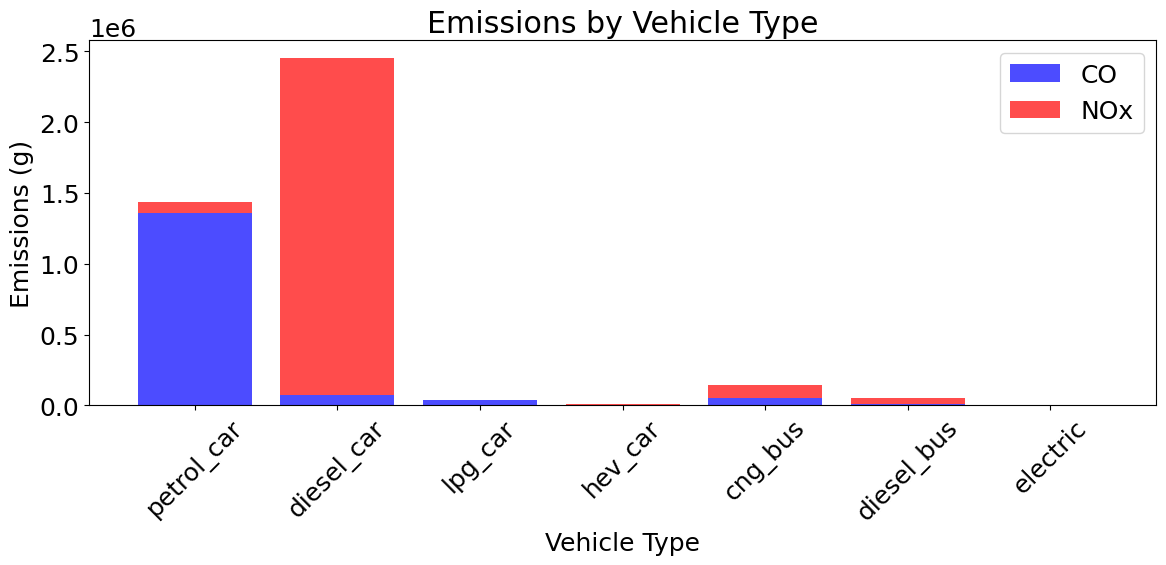

In [69]:
plt.rcParams.update({'font.size': 18})
#Bar plot for vehicle types and their emissions
plt.figure(figsize=(12, 6))
plt.bar(vehicle_df["vehicle_type"], vehicle_df["CO"], color='blue', alpha=0.7, label="CO")
plt.bar(vehicle_df["vehicle_type"], vehicle_df["NOx"], color='red', alpha=0.7, label="NOx", bottom=vehicle_df["CO"])
plt.xlabel("Vehicle Type")
plt.ylabel("Emissions (g)")
plt.title("Emissions by Vehicle Type")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('emissions/output/plots/vehicle_emissions.png')
plt.show()

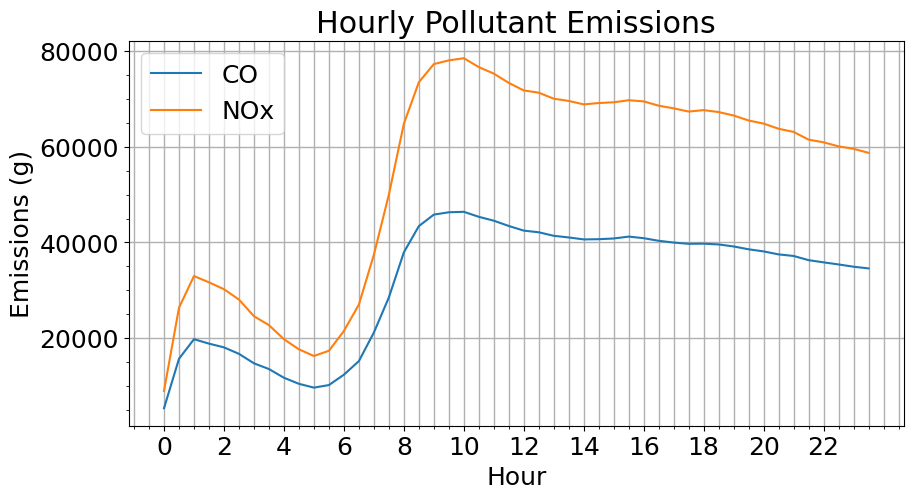

In [70]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(temporal_df["hour"], temporal_df["CO"], label="CO")
ax.plot(temporal_df["hour"], temporal_df["NOx"], label="NOx")

# Major ticks every 2 hours (labels)
ax.set_xticks(np.arange(0, 24, 2))

# Minor ticks every 1 hour (no labels)
ax.set_xticks(np.arange(0, 24, 1), minor=True)

# IMPORTANT: turn on minor ticks display
ax.minorticks_on()

# Grid only for minor ticks (1-hour grid)
ax.grid(which='both', axis='x', linewidth=1)
ax.grid(which='major', axis='y', linewidth=1)

ax.set_xlabel("Hour")
ax.set_ylabel("Emissions (g)")
ax.set_title("Hourly Pollutant Emissions")
ax.legend()


plt.savefig('emissions/output/plots/hourly_emissions.png')

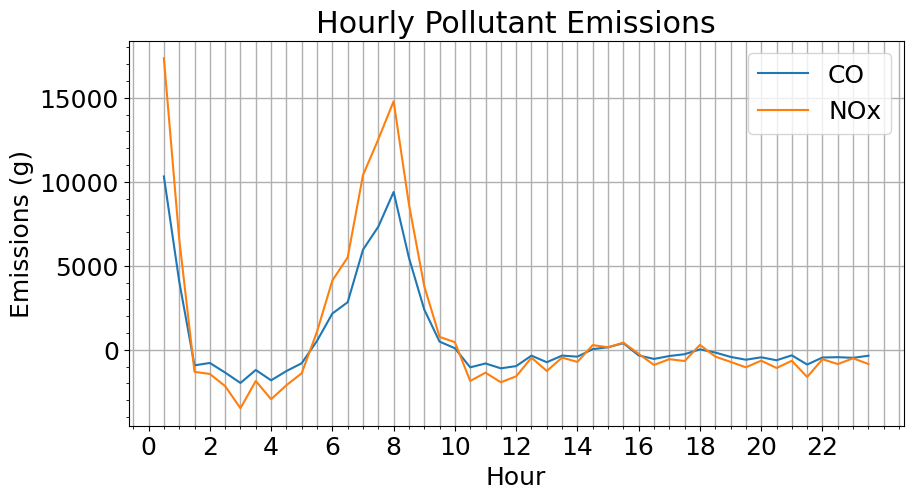

In [71]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(temporal_df["hour"], temporal_df["CO"].diff(), label="CO")
ax.plot(temporal_df["hour"], temporal_df["NOx"].diff(), label="NOx")

# Major ticks every 2 hours (labels)
ax.set_xticks(np.arange(0, 24, 2))

# Minor ticks every 1 hour (no labels)
ax.set_xticks(np.arange(0, 24, 1), minor=True)

# IMPORTANT: turn on minor ticks display
ax.minorticks_on()

# Grid only for minor ticks (1-hour grid)
ax.grid(which='both', axis='x', linewidth=1)
ax.grid(which='major', axis='y', linewidth=1)

ax.set_xlabel("Hour")
ax.set_ylabel("Emissions (g)")
ax.set_title("Hourly Pollutant Emissions")
ax.legend()

plt.savefig('emissions/output/plots/hourly_emissions_derivative.png')

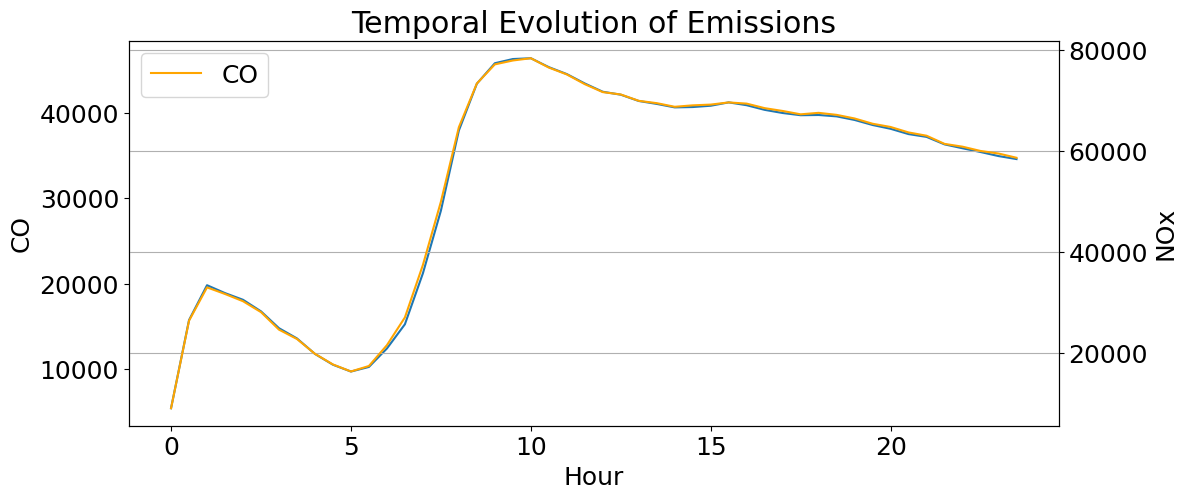

In [72]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    temporal_df["hour"],
    temporal_df["CO"]
)

ax1.set_xlabel("Hour")
ax1.set_ylabel("CO")

ax2 = ax1.twinx()

ax2.plot(
    temporal_df["hour"],
    temporal_df["NOx"],
    color='orange'
)

ax2.set_ylabel("NOx")

plt.title("Temporal Evolution of Emissions")
plt.grid(True)
plt.legend(["CO", "NOx"], loc="upper left")

plt.savefig('emissions/output/plots/temporal_emissions.png')

In [73]:
daily_gdf = spatial_gdf.groupby(
    ["i", "j"],
    as_index=False
).agg({
    "CO": "sum",
    "NOx": "sum",
    "vehicles": "sum",
    "geometry": "first"
})

daily_gdf = gpd.GeoDataFrame(
    daily_gdf,
    geometry="geometry"
)

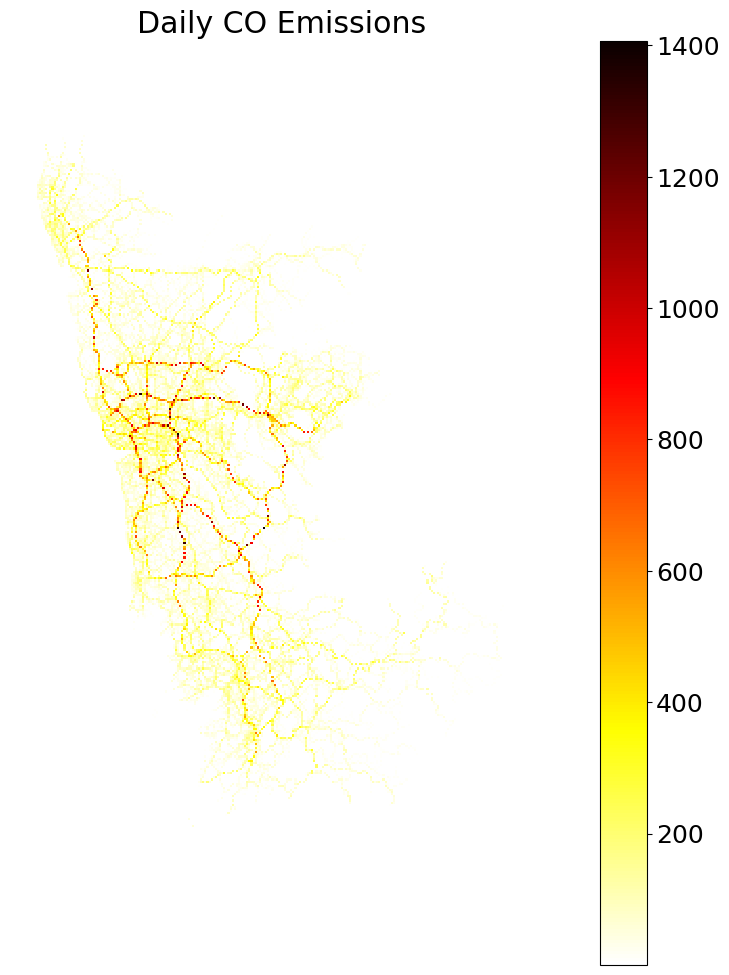

In [74]:
fig, ax = plt.subplots(figsize=(12,12))

daily_gdf.plot(
    column="CO",
    cmap="hot_r",
    label="CO Emissions",
    legend=True,
    ax=ax
)

ax.set_title("Daily CO Emissions")

ax.set_axis_off()

plt.savefig('emissions/output/plots/spatial_emissions.png')

In [75]:
daily_gdf["log_CO"] = np.log1p(
    daily_gdf["CO"]
)

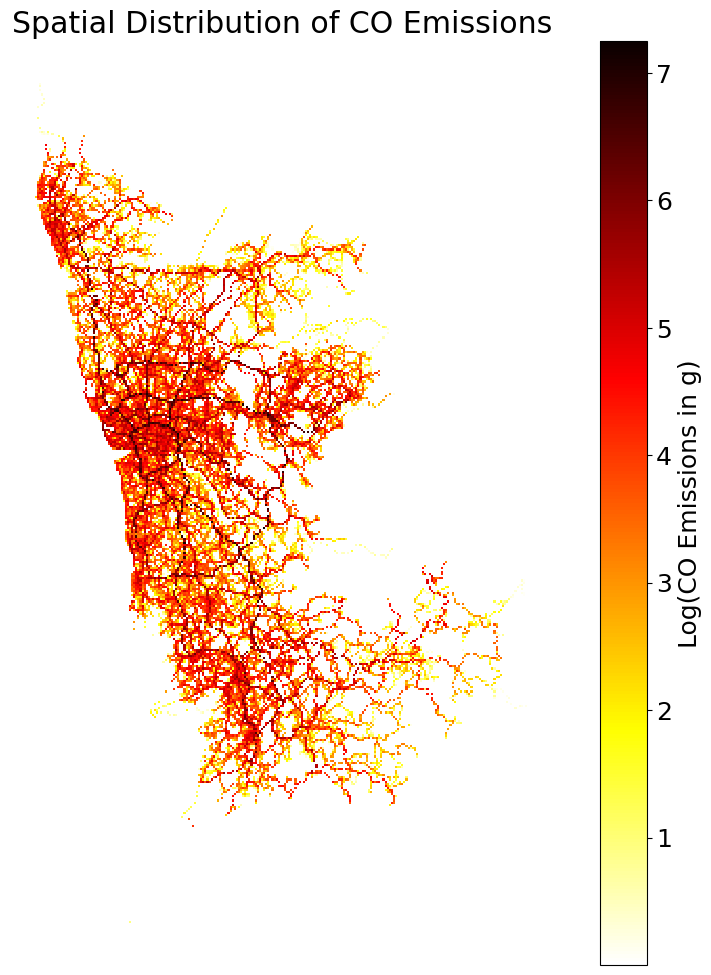

In [76]:
fig, ax = plt.subplots(figsize=(12,12))

daily_gdf.plot(
    column="log_CO",
    cmap="hot_r",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Log(CO Emissions in g)", "orientation": "vertical"}
)

ax.set_title("Spatial Distribution of CO Emissions")

ax.set_axis_off()

plt.savefig('emissions/output/plots/spatial_emissions_log.png')

In [77]:
morning_gdf = spatial_gdf[
    spatial_gdf["time_bin"].between(6, 10)
]
morning_gdf = morning_gdf.groupby(
    ["i", "j"],
    as_index=False
).agg({
    "CO": "sum",
    "geometry": "first"
})

morning_gdf = gpd.GeoDataFrame(
    morning_gdf,
    geometry="geometry"
)


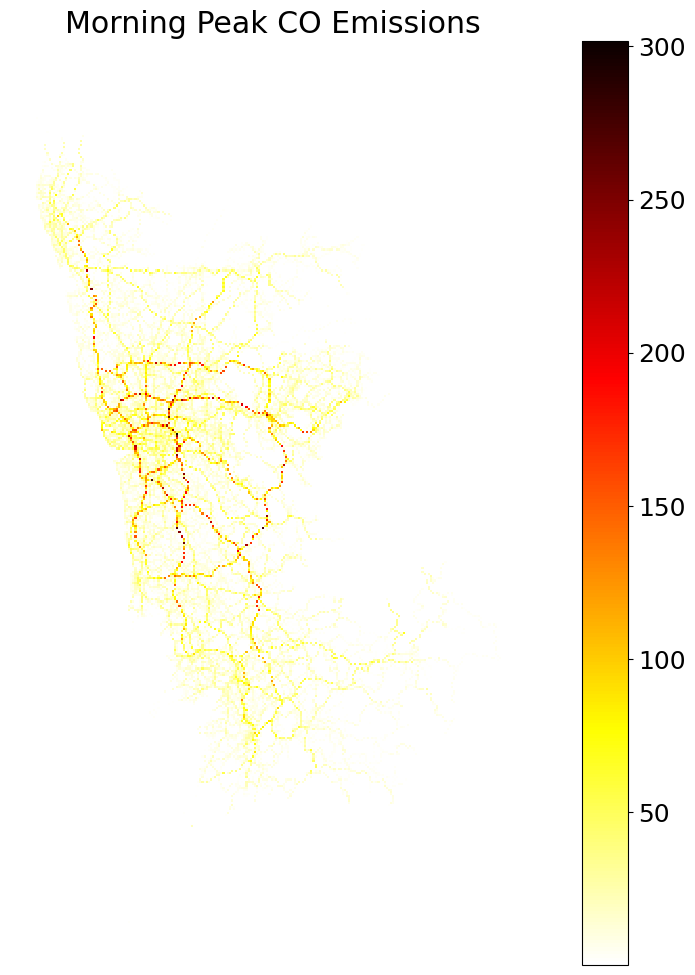

In [78]:
fig, ax = plt.subplots(figsize=(12,12))

morning_gdf.plot(
    column="CO",
    cmap="hot_r",
    legend=True,
    ax=ax
)

ax.set_title("Morning Peak CO Emissions")

ax.set_axis_off()
plt.savefig('emissions/output/plots/morning_peak_emissions.png')

In [79]:
top_cells = daily_gdf.nlargest(
    20,
    "CO"
)[[
    "i",
    "j",
    "CO",
    "NOx",
    "vehicles"
]]
daily_gdf["CO_per_vehicle"] = (
    daily_gdf["CO"] /
    daily_gdf["vehicles"]
)

In [42]:
minx, miny, maxx, maxy = spatial_gdf.total_bounds

spatial_gdf["log_CO"] = np.log1p(
    spatial_gdf["CO"]
)

for hour in sorted(spatial_gdf["time_bin"].unique()):

    print(f"Processing hour {hour}...")
    
    hour_gdf = spatial_gdf[
        spatial_gdf["time_bin"] == hour
    ]

    fig, ax = plt.subplots(figsize=(12,12))

    hour_gdf.plot(
        column="log_CO",
        cmap="hot_r",
        legend=False,
        ax=ax
    )

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    ax.set_title(f"Hour {hour}")
    ax.set_axis_off()

    plt.savefig(
        f"emissions/output/plots/gif/hour_{hour}.png",
        dpi=150
    )

    plt.close()

Processing hour 0.0...
Processing hour 0.5...
Processing hour 1.0...
Processing hour 1.5...
Processing hour 2.0...
Processing hour 2.5...
Processing hour 3.0...
Processing hour 3.5...
Processing hour 4.0...
Processing hour 4.5...
Processing hour 5.0...
Processing hour 5.5...
Processing hour 6.0...
Processing hour 6.5...
Processing hour 7.0...
Processing hour 7.5...
Processing hour 8.0...
Processing hour 8.5...
Processing hour 9.0...
Processing hour 9.5...
Processing hour 10.0...
Processing hour 10.5...
Processing hour 11.0...
Processing hour 11.5...
Processing hour 12.0...
Processing hour 12.5...
Processing hour 13.0...
Processing hour 13.5...
Processing hour 14.0...
Processing hour 14.5...
Processing hour 15.0...
Processing hour 15.5...
Processing hour 16.0...
Processing hour 16.5...
Processing hour 17.0...
Processing hour 17.5...
Processing hour 18.0...
Processing hour 18.5...
Processing hour 19.0...
Processing hour 19.5...
Processing hour 20.0...
Processing hour 20.5...
Processing h